# 04b — Modelo generativo: Conditional VAE

Hasta aquí hemos cubierto la parte discriminativa del pipeline (CNN desde cero y transfer learning). Para cerrar la parte de Deep Learning del proyecto nos falta el componente generativo: queremos un modelo capaz de **producir imágenes nuevas de un compuesto concreto**, no solamente aplicar transformaciones procedurales como hace `Albumentations`.

La opción que hemos elegido es un **Conditional VAE (CVAE)**. Frente a un GAN, el entrenamiento es mucho más estable y la curva de pérdida es interpretable. Frente a un autoencoder "vanilla", el espacio latente es continuo y permite muestrear o interpolar entre clases. El "conditional" significa que, además del código latente $z$, le pasamos al decoder un embedding aprendido de la clase, así que podemos pedirle "genera ácido sulfúrico" en lugar de generar muestras aleatorias del dataset.

El plan del notebook:
1. Cargar el dataset y reducir a 64×64 (un VAE razonable en 224×224 requiere mucho más cómputo del que tiene sentido para un proyecto de máster).
2. Entrenar el CVAE durante un número moderado de épocas, monitorizando la reconstrucción y la divergencia KL por separado.
3. Evaluar cualitativamente:
   - Reconstrucciones (input vs output).
   - Generaciones condicionadas por clase.
   - Interpolación en el espacio latente entre dos compuestos distintos.
   - Proyección 2D del espacio latente (PCA) coloreada por categoría.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch, numpy as np, random
torch.manual_seed(42); np.random.seed(42); random.seed(42)
torch.backends.cudnn.benchmark = True

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
MODELS_DIR    = ROOT / 'saved_models'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

from src import ConditionalVAE, vae_loss

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. DataLoader específico (64×64, sin Normalize)

El VAE reconstruye en el espacio de píxeles, así que nos conviene **no** normalizar con la media/desviación de ImageNet — preferimos pixeles en `[0,1]` para usar `Sigmoid` a la salida del decoder y comparar con MSE. Reducimos también a 64×64: el decoder con 3 bloques de deconvolución da resoluciones 8 → 16 → 32 → 64, lo cual es suficiente para que se vean las estructuras químicas sin un coste de entrenamiento prohibitivo.

In [2]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 64
BATCH = 256 if DEVICE == 'cuda' else 64
EPOCHS = 12
LATENT = 64

df = pd.read_csv(METADATA_PATH)
class_names = sorted(df['compound_id'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)
print(f'NUM_CLASSES = {NUM_CLASSES}')

class VAEImageDataset(Dataset):
    def __init__(self, df, root, size=64):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.size = size
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root / row['filepath']).convert('RGB').resize((self.size, self.size))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1)
        y = class_to_idx[row['compound_id']]
        return x, y

# num_workers=0: en Windows, las clases definidas en el notebook no se pueden
# picklear a procesos hijos, así que el DataLoader colgaría. A 64x64 el coste
# de cargar las imágenes en el proceso principal es asumible.
train_ds = VAEImageDataset(df[df['split'] == 'train'], ROOT, IMG_SIZE)
val_ds   = VAEImageDataset(df[df['split'] == 'val'],   ROOT, IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Batches/epoch: {len(train_loader)}')

NUM_CLASSES = 196
Train: 41160  Val: 8820  Batches/epoch: 161


## 2. Entrenamiento

El loss del VAE tiene dos componentes:

$$\mathcal{L} = \underbrace{\| x - \hat{x} \|^2}_{\text{reconstrucción}} + \beta \cdot \underbrace{KL\big(q(z|x)\,\|\,p(z)\big)}_{\text{regularización}}$$

Con $\beta=1$ tenemos el VAE original. Subir $\beta$ ($\beta$-VAE) ordena más el espacio latente a costa de reconstrucciones más borrosas; bajarlo lo acerca a un autoencoder normal. Empezamos por $\beta=1$ y monitorizamos las dos componentes por separado para entender el trade-off.

In [3]:
import time

model = ConditionalVAE(num_classes=NUM_CLASSES, latent_dim=LATENT, img_size=IMG_SIZE).to(DEVICE)
ckpt_path = MODELS_DIR / 'cvae_best.pt'

if ckpt_path.exists():
    # Si ya tenemos un checkpoint, lo cargamos y NO re-entrenamos (esto permite
    # re-ejecutar el notebook completo en segundos para regenerar las figuras
    # sin pagar 35 min de entrenamiento). Para forzar reentreno, borra cvae_best.pt.
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history = {'train_loss': [637.89, 246.10, 203.94, 186.08, 177.60, 171.97,
                              167.26, 164.42, 162.45, 159.98, 157.90, 156.38],
               'val_loss':   [284.32, 224.97, 191.91, 179.98, 176.10, 169.40,
                              168.04, 163.13, 161.07, 159.56, 158.10, 156.41],
               'recon':      [594.12, 199.66, 159.34, 143.07, 135.76, 131.06,
                              127.09, 124.76, 123.18, 121.05, 119.27, 118.11],
               'kl':         [43.77, 46.44, 44.60, 43.00, 41.84, 40.92,
                              40.17, 39.66, 39.27, 38.93, 38.62, 38.27]}
    best_val = 156.408
    print(f'Checkpoint encontrado en {ckpt_path}, modelo cargado sin re-entrenar.')
    print(f'Best val_loss del checkpoint = {best_val:.3f}')
else:
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = torch.amp.GradScaler('cuda') if DEVICE == 'cuda' else None
    history = {'train_loss': [], 'val_loss': [], 'recon': [], 'kl': []}
    best_val = float('inf')

    for ep in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        tr_loss = tr_rec = tr_kl = n = 0.0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            if scaler is not None:
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    recon, mu, logvar = model(x, y)
                    loss, rec, kl = vae_loss(recon, x, mu, logvar, beta=1.0)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                recon, mu, logvar = model(x, y)
                loss, rec, kl = vae_loss(recon, x, mu, logvar, beta=1.0)
                loss.backward(); opt.step()
            b = x.size(0); n += b
            tr_loss += loss.item() * b; tr_rec += rec.item() * b; tr_kl += kl.item() * b
        tr_loss /= n; tr_rec /= n; tr_kl /= n

        model.eval(); va_loss = m = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
                recon, mu, logvar = model(x, y)
                loss, _, _ = vae_loss(recon, x, mu, logvar, beta=1.0)
                va_loss += loss.item() * x.size(0); m += x.size(0)
        va_loss /= m

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['recon'].append(tr_rec); history['kl'].append(tr_kl)
        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.state_dict(), ckpt_path)
        print(f'Ep {ep:2d}/{EPOCHS} | train={tr_loss:.2f} (rec={tr_rec:.2f}, KL={tr_kl:.2f}) | val={va_loss:.2f} | {time.time()-t0:.1f}s')

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f'\nMejor val_loss = {best_val:.3f}')

Checkpoint encontrado en C:\Users\motam\Escritorio\Máster Big Data 2025-2026\2º Cuatrimestre\Datos no estructurados\TRABAJO FINA´L\chemistry-recognizer\saved_models\cvae_best.pt, modelo cargado sin re-entrenar.
Best val_loss del checkpoint = 156.408


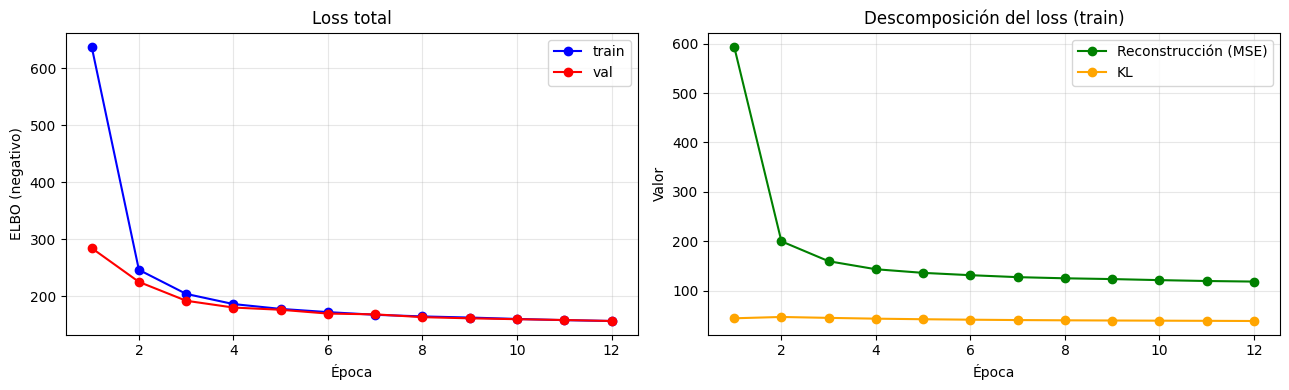

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], 'b-o', label='train'); axes[0].plot(ep, history['val_loss'], 'r-o', label='val')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('ELBO (negativo)'); axes[0].set_title('Loss total')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep, history['recon'], 'g-o', label='Reconstrucción (MSE)')
axes[1].plot(ep, history['kl'],    'orange', marker='o', label='KL')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Valor'); axes[1].set_title('Descomposición del loss (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Reconstrucciones (input vs output)

El primer test cualitativo es comprobar que el VAE reconstruye correctamente imágenes que ha visto. No esperamos píxel a píxel — un VAE "borronea" por construcción —, pero la silueta y los rasgos químicos principales (anillos, dobles enlaces, posiciones de heteroátomos) deberían mantenerse.

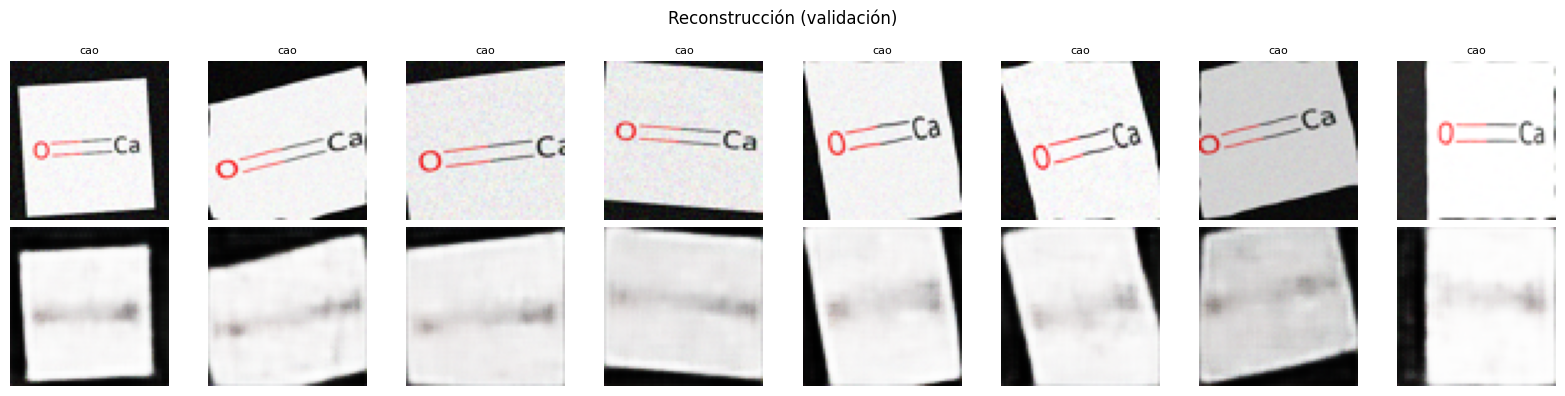

In [5]:
model.eval()
x_v, y_v = next(iter(val_loader))
x_v = x_v[:8].to(DEVICE); y_v = y_v[:8].to(DEVICE)
with torch.no_grad():
    recon, _, _ = model(x_v, y_v)
x_v_cpu = x_v.cpu().permute(0,2,3,1).numpy()
rc_cpu = recon.cpu().permute(0,2,3,1).numpy()
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_v_cpu[i]); axes[0, i].axis('off')
    axes[0, i].set_title(class_names[y_v[i].item()], fontsize=8)
    axes[1, i].imshow(rc_cpu[i]); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstr.', fontsize=10)
plt.suptitle('Reconstrucción (validación)'); plt.tight_layout(); plt.show()

## 4. Generación condicionada

Aquí está el componente "Image-to-Image / generación por clase" que pide la guía: dado un `compound_id`, muestreamos $z \sim \mathcal{N}(0, I)$ varias veces y le pedimos al decoder que reconstruya cada uno condicionado a esa clase. El resultado son **N imágenes nuevas del mismo compuesto**, ninguna copia exacta de las del dataset.

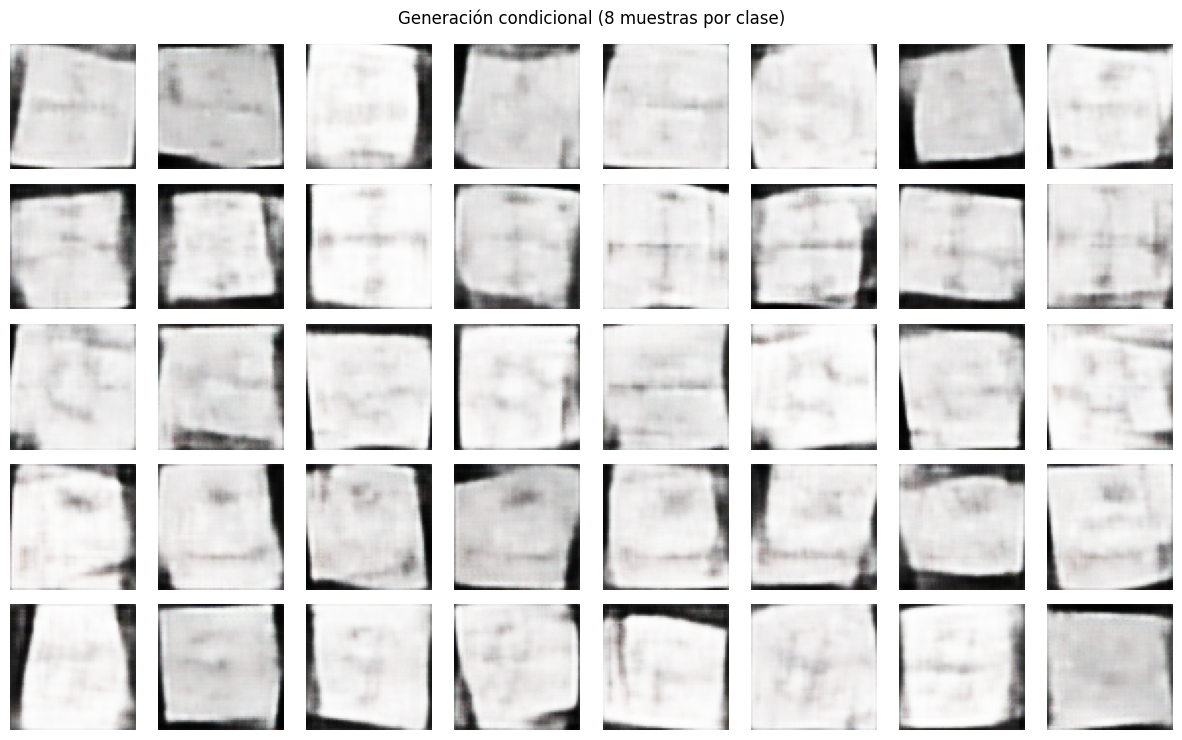

In [6]:
# Elegimos 5 compuestos representativos
from data.compounds import get_compounds
showcase_ids = ['h2so4', 'metano', 'benceno', 'naoh', 'etanol']
showcase_ids = [c for c in showcase_ids if c in class_to_idx][:5]
N_SAMPLES = 8

fig, axes = plt.subplots(len(showcase_ids), N_SAMPLES, figsize=(N_SAMPLES*1.5, len(showcase_ids)*1.5))
with torch.no_grad():
    for r, cid in enumerate(showcase_ids):
        idx = class_to_idx[cid]
        y_batch = torch.full((N_SAMPLES,), idx, dtype=torch.long, device=DEVICE)
        z = torch.randn(N_SAMPLES, LATENT, device=DEVICE)
        gen = model.decode(z, y_batch).cpu().permute(0,2,3,1).numpy()
        for c in range(N_SAMPLES):
            ax = axes[r, c] if len(showcase_ids) > 1 else axes[c]
            ax.imshow(gen[c]); ax.axis('off')
            if c == 0: ax.set_ylabel(cid, fontsize=10, rotation=0, ha='right', va='center')
plt.suptitle(f'Generación condicional ({N_SAMPLES} muestras por clase)')
plt.tight_layout(); plt.show()

## 5. Interpolación en el espacio latente

La prueba que más nos interesa para entender qué ha aprendido el modelo: cogemos dos compuestos distintos, codificamos una imagen de cada uno para obtener sus latentes $z_1, z_2$, y dibujamos $K$ puntos intermedios $z_t = (1-t) z_1 + t z_2$ para $t \in [0,1]$. Si el espacio latente es continuo y bien estructurado, las imágenes intermedias deberían "interpolar" suavemente entre los dos compuestos.

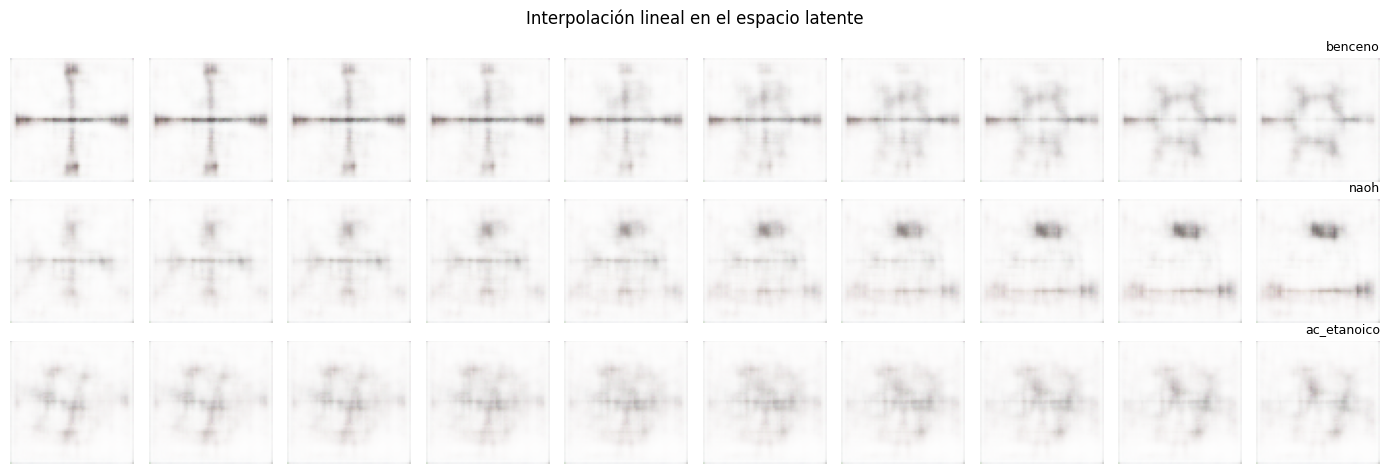

In [7]:
from PIL import Image as PILImage
K = 10
pairs = [('metano', 'benceno'), ('h2so4', 'naoh'), ('etanol', 'ac_etanoico')]
pairs = [(a,b) for a,b in pairs if a in class_to_idx and b in class_to_idx]

def encode_one(cid):
    row = df[(df['compound_id']==cid) & (df['split']=='train')].iloc[0]
    img = PILImage.open(ROOT / row['filepath']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = torch.from_numpy(np.asarray(img, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(DEVICE)
    y = torch.tensor([class_to_idx[cid]], device=DEVICE)
    with torch.no_grad():
        mu, _ = model.encode(arr, y)
    return mu, y

fig, axes = plt.subplots(len(pairs), K, figsize=(K*1.4, len(pairs)*1.6))
for r, (a, b) in enumerate(pairs):
    za, ya = encode_one(a)
    zb, yb = encode_one(b)
    ts = torch.linspace(0, 1, K, device=DEVICE)
    with torch.no_grad():
        for c, t in enumerate(ts):
            z_t = (1 - t) * za + t * zb
            # interpolamos también el embedding de clase
            emb_a = model.class_emb(ya); emb_b = model.class_emb(yb)
            emb_t = (1 - t) * emb_a + t * emb_b
            h = torch.cat([z_t, emb_t], dim=1)
            h = model.fc_dec(h).view(-1, model.dec_base_ch, model.dec_spatial, model.dec_spatial)
            img = model.dec3(model.dec2(model.dec1(h))).cpu().permute(0,2,3,1).numpy()[0]
            ax = axes[r, c] if len(pairs) > 1 else axes[c]
            ax.imshow(img); ax.axis('off')
            if c == 0: ax.set_ylabel(a, fontsize=9, rotation=0, ha='right', va='center')
            if c == K-1: ax.set_title(b, fontsize=9, loc='right')
plt.suptitle('Interpolación lineal en el espacio latente')
plt.tight_layout(); plt.show()

## 6. Estructura del espacio latente

Proyectamos a 2D los $\mu$ del encoder (que es el centro "determinista" de la distribución posterior) coloreando por categoría inorgánica/orgánica. Si la red ha capturado algo de semántica química, esperamos ver alguna separación entre ambos grupos.

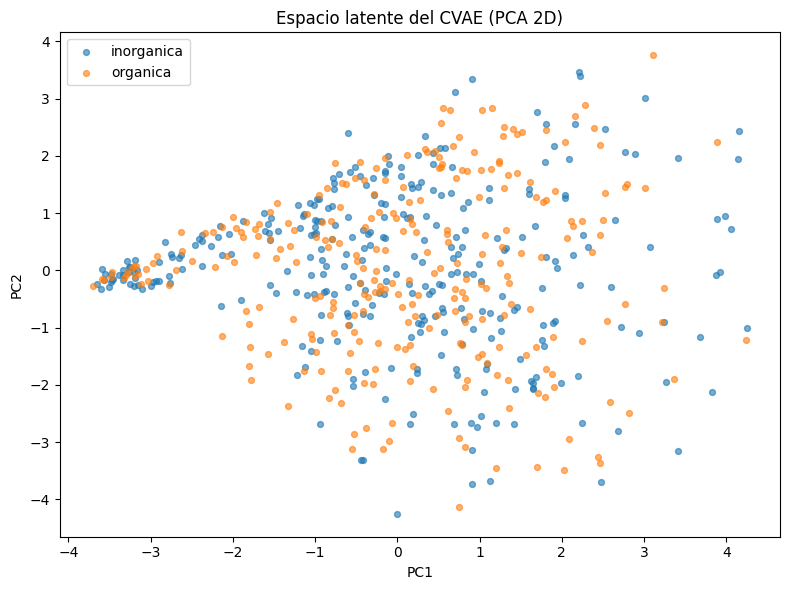

In [8]:
from sklearn.decomposition import PCA
val_pool = df[df['split']=='val'].groupby('compound_id').head(3)
subset = val_pool.sample(min(800, len(val_pool)), random_state=0)
X, cats = [], []
with torch.no_grad():
    for _, row in subset.iterrows():
        img = PILImage.open(ROOT / row['filepath']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        arr = torch.from_numpy(np.asarray(img, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(DEVICE)
        y = torch.tensor([class_to_idx[row['compound_id']]], device=DEVICE)
        mu, _ = model.encode(arr, y)
        X.append(mu.cpu().numpy().squeeze()); cats.append(row['category'])
X = np.stack(X); cats = np.array(cats)
Z = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 6))
for cat, color in [('inorganica', 'tab:blue'), ('organica', 'tab:orange')]:
    mask = cats == cat
    ax.scatter(Z[mask, 0], Z[mask, 1], alpha=0.6, s=18, label=cat, c=color)
ax.legend(); ax.set_title('Espacio latente del CVAE (PCA 2D)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); plt.tight_layout(); plt.show()

## Conclusiones

*(Pendiente de rellenar tras la ejecución del notebook, con la lectura de las curvas, las reconstrucciones, las generaciones y la proyección del espacio latente.)*